In [107]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings("ignore")

# Load and standardize the dataset
bc_data = load_breast_cancer()
bc_X = pd.DataFrame(bc_data.data, columns=bc_data.feature_names)
scaler = StandardScaler()
bc_X_standardized = scaler.fit_transform(bc_X)

In [108]:
# Load the Yeast dataset
yeast_data = fetch_openml(data_id=181, as_frame=True)
yeast_df = yeast_data.frame
yeast_df["target"] = yeast_data.target

# Identify categorical columns
categorical_columns = yeast_df.select_dtypes(include=["category"]).columns
non_categorical_columns = yeast_df.select_dtypes(exclude=["category"]).columns

# One-hot encode categorical columns
yeast_features_dummy = pd.get_dummies(
    yeast_df, columns=categorical_columns, drop_first=True
)
# other features are non-categorical
yest_features_non_dummy = yeast_df[non_categorical_columns]

# join the non-categorical columns
yeast_features = pd.concat([yeast_features_dummy, yest_features_non_dummy], axis=1)

yeast_X_standardized = scaler.fit_transform(yeast_features)

In [109]:
# print the shape of the datasets
print(f"Yeast Dataset Shape: {yeast_X_standardized.shape}")
print(f"Breast Cancer Dataset Shape: {bc_X_standardized.shape}")

Yeast Dataset Shape: (1484, 34)
Breast Cancer Dataset Shape: (569, 30)


In [110]:
# %%
yeast_rank = np.linalg.matrix_rank(yeast_X_standardized)
bc_rank = np.linalg.matrix_rank(bc_X_standardized)
print(f"Rank of Yeast Dataset: {yeast_rank}")
print(f"Rank of Breast Cancer Dataset: {bc_rank}")

Rank of Yeast Dataset: 17
Rank of Breast Cancer Dataset: 30


In [116]:
# Compute number of components to capture 95% variance for PCA
def pca_components_for_variance(data, variance_threshold=0.95):
    data = StandardScaler().fit_transform(data)
    pca = PCA().fit(data)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    num_components = np.argmax(cumulative_variance >= variance_threshold) + 1
    return num_components, pca.explained_variance_ratio_


yeast_pca_components, yeast_explained_variance_ratio = pca_components_for_variance(
    yeast_X_standardized
)
bc_pca_components, bc__explained_variance_ratio = pca_components_for_variance(
    bc_X_standardized
)

print(
    f"Number of PCA components to capture 95% variance for Yeast dataset: {yeast_pca_components}"
)
print(
    f"Number of PCA components to capture 95% variance for Breast Cancer dataset: {bc_pca_components}"
)

Number of PCA components to capture 95% variance for Yeast dataset: 15
Number of PCA components to capture 95% variance for Breast Cancer dataset: 10
Explained variance ratio for Yeast dataset: [1.45997728e-01 1.07085180e-01 9.82047096e-02 9.47176653e-02
 8.52339355e-02 6.96829955e-02 6.46156646e-02 6.14095316e-02
 5.42251028e-02 5.00159320e-02 3.33274041e-02 3.15364735e-02
 2.55216438e-02 2.25755473e-02 2.14377375e-02 2.06546226e-02
 1.37581253e-02 7.00567924e-16 5.10550948e-16 9.52839576e-17
 8.78083734e-17 2.51284341e-17 1.32263159e-18 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
Explained variance ratio for Breast Cancer dataset: [4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.662

Number of ICA components for Yeast dataset: 4
Number of ICA components for Breast Cancer dataset: 29


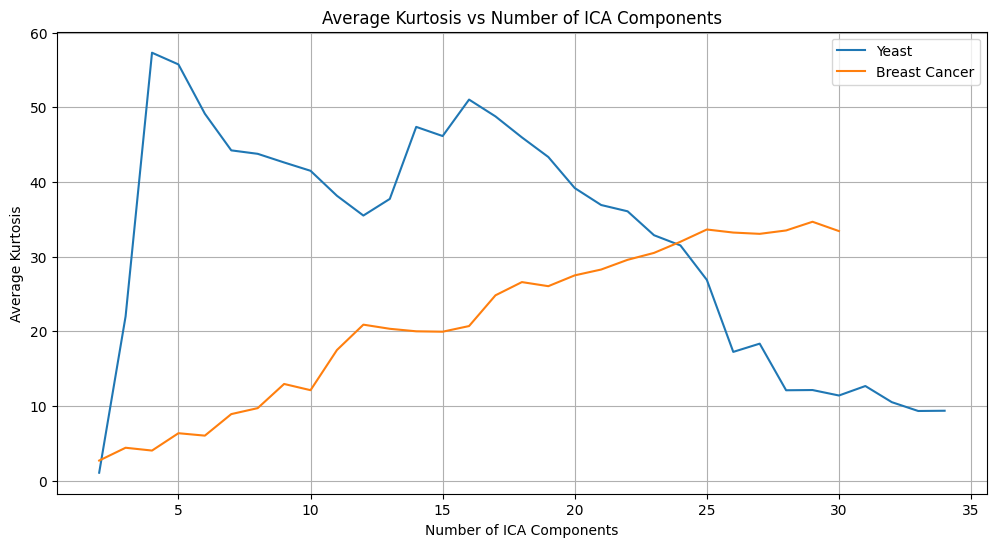

In [115]:
from scipy.stats import kurtosis
import matplotlib.pyplot as plt


# Compute number of components that have lowest reconstruction error for ICA
def ica_kurtosis_components(data):
    data_scaled = StandardScaler().fit_transform(data)
    ica = FastICA(random_state=42, tol=1e-4)
    kurtoses = []

    for n_components in range(2, data.shape[1] + 1):
        ica.set_params(n_components=n_components)
        transformed_data = ica.fit_transform(data_scaled)
        component_kurtoses = kurtosis(transformed_data, fisher=True)
        kurtoses.append(np.mean(component_kurtoses))

    # Find the optimal number of components with maximum kurtosis
    optimal_components = np.argmax(kurtoses) + 2  # +2 because range starts from 2
    return optimal_components, kurtoses


yeast_ica_components, yeast_kurtoses = ica_kurtosis_components(yeast_X_standardized)
bc_ica_components, bc_kurtoses = ica_kurtosis_components(bc_X_standardized)

print(f"Number of ICA components for Yeast dataset: {yeast_ica_components}")
print(f"Number of ICA components for Breast Cancer dataset: {bc_ica_components}")

# Plotting the kurtosis for each number of components
plt.figure(figsize=(12, 6))
plt.plot(range(2, yeast_features.shape[1] + 1), yeast_kurtoses, label="Yeast")
plt.plot(
    range(2, bc_X_standardized.shape[1] + 1),
    bc_kurtoses,
    label="Breast Cancer",
)
plt.xlabel("Number of ICA Components")
plt.ylabel("Average Kurtosis")
plt.title("Average Kurtosis vs Number of ICA Components")
plt.legend()
plt.grid(True)
plt.show()

In [120]:
# the distribution of kurtosis values for the optimal number of components
def ica_kurtosis_distribution(data, n_components):
    data_scaled = StandardScaler().fit_transform(data)
    ica = FastICA(n_components=n_components, random_state=42, tol=1e-4)
    transformed_data = ica.fit_transform(data_scaled)
    component_kurtoses = kurtosis(transformed_data, fisher=True)
    return component_kurtoses


bc_kurtoses_distribution = ica_kurtosis_distribution(
    bc_X_standardized, bc_ica_components
)
yeast_kurtoses_distribution = ica_kurtosis_distribution(
    yeast_X_standardized, yeast_ica_components
)

print(
    f"Optimal Kurtosis distribution for Breast Cancer dataset: {bc_kurtoses_distribution} when n_components = {bc_ica_components}"
)
print(
    f"Optimal Kurtosis distribution for Yeast dataset: {yeast_kurtoses_distribution}"
    f" when n_components = {yeast_ica_components}"
)

Optimal Kurtosis distribution for Breast Cancer dataset: [  3.28701259   7.65719587   7.40245108  64.98084698  11.28810914
   4.49404648   4.91983546   7.16085467  -0.33949196  23.4194961
  33.31595371  14.58922302   3.7183976   10.98388462  34.34417146
 243.01456353   1.72685087   5.9411234    4.31335548  20.43855301
  47.57189891  15.20668919  62.04721267   2.68249065   4.0496128
   7.05037475   1.69229804 281.18282258  77.45096489] when n_components = 29
Optimal Kurtosis distribution for Yeast dataset: [143.97895912  83.52014079   0.97009788   0.78891548] when n_components = 4


In [ ]:
# calculate VIF
def calculate_vif(data):
    values = scaler.fit_transform(data)
    vif_data = pd.DataFrame()
    vif_data["feature"] = data.columns
    vif_data["VIF"] = [
        variance_inflation_factor(values, i) for i in range(len(data.columns))
    ]
    return vif_data


yeast_vif = calculate_vif(yest_features_non_dummy)

In [ ]:
bc_vif = calculate_vif(bc_X)

In [ ]:
# how many components are correlated
vif_threadhold = 5
yeast_vif_components = yeast_vif[yeast_vif["VIF"] > vif_threadhold].shape[0]
bc_vif_components = bc_vif[bc_vif["VIF"] > vif_threadhold].shape[0]
print(f"Number of VIF components for Yeast dataset: {yeast_vif_components}")
print(f"Number of VIF components for Breast Cancer dataset: {bc_vif_components}")

Number of VIF components for Yeast dataset: 0
Number of VIF components for Breast Cancer dataset: 27
